In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("../data/processed/experiment_data_clean.csv")

# Basic info
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()

Shape: (50000, 20)

Columns:
['user_id', 'session_id', 'variant', 'device_type', 'traffic_source', 'country', 'is_new_user', 'age_group', 'pages_viewed', 'clicked_recommendation', 'watch_started', 'minutes_watched', 'signed_up', 'retained_7d', 'session_duration_sec', 'subscription_status', 'conversion', 'engaged_user', 'high_watch_time', 'retention_proxy']


,user_id,session_id,variant,device_type,traffic_source,country,is_new_user,age_group,pages_viewed,clicked_recommendation,watch_started,minutes_watched,signed_up,retained_7d,session_duration_sec,subscription_status,conversion,engaged_user,high_watch_time,retention_proxy
0,25795,1,a,mobile,organic,canada,1,18-24,3,0,1,32.03,0,1,517,not_subscribed,0,1,1,1
1,10860,2,a,mobile,organic,canada,1,45-54,8,0,0,0.89,0,0,456,not_subscribed,0,1,0,0
2,86820,3,a,mobile,organic,india,1,25-34,4,0,0,1.13,0,1,80,not_subscribed,0,1,0,1
3,64886,4,b,tablet,organic,us,0,55+,6,1,0,2.50,0,0,283,not_subscribed,0,1,0,0
4,16265,5,a,desktop,organic,us,0,35-44,4,0,0,0.63,0,0,200,not_subscribed,0,1,0,0


In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nVariant counts:")
print(df["variant"].value_counts())

print("\nVariant proportions:")
print(df["variant"].value_counts(normalize=True))

Missing values:
user_id                   0
session_id                0
variant                   0
device_type               0
traffic_source            0
country                   0
is_new_user               0
age_group                 0
pages_viewed              0
clicked_recommendation    0
watch_started             0
minutes_watched           0
signed_up                 0
retained_7d               0
session_duration_sec      0
subscription_status       0
conversion                0
engaged_user              0
high_watch_time           0
retention_proxy           0
dtype: int64

Variant counts:
variant
a    25026
b    24974
Name: count, dtype: int64

Variant proportions:
variant
a    0.50052
b    0.49948
Name: proportion, dtype: float64


In [5]:
summary = df.groupby("variant").agg(
    sessions=("session_id", "count"),
    signup_rate=("signed_up", "mean"),
    watch_start_rate=("watch_started", "mean"),
    click_rate=("clicked_recommendation", "mean"),
    avg_session_duration=("session_duration_sec", "mean"),
    avg_minutes_watched=("minutes_watched", "mean"),
    retention_rate=("retained_7d", "mean")
).reset_index()

summary

,variant,sessions,signup_rate,watch_start_rate,click_rate,avg_session_duration,avg_minutes_watched,retention_rate
0,a,25026,0.060537,0.135739,0.225965,249.524734,5.831286,0.112603
1,b,24974,0.068031,0.156483,0.253103,256.793826,6.311910,0.112837


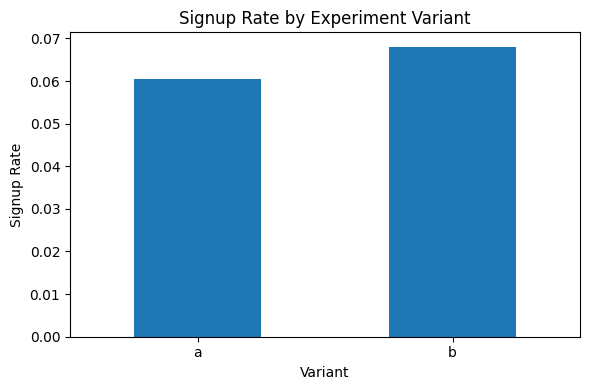

In [6]:
signup_rate = df.groupby("variant")["signed_up"].mean()

plt.figure(figsize=(6, 4))
signup_rate.plot(kind="bar")
plt.title("Signup Rate by Experiment Variant")
plt.xlabel("Variant")
plt.ylabel("Signup Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

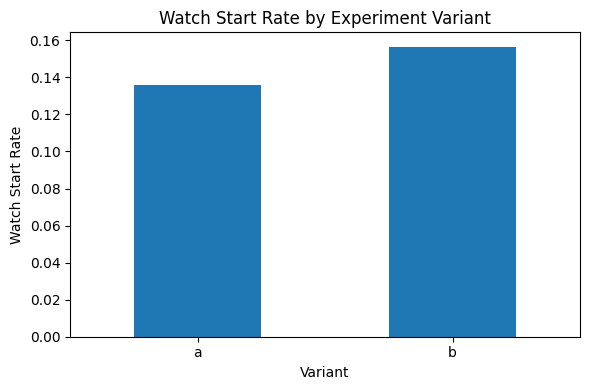

In [7]:
watch_rate = df.groupby("variant")["watch_started"].mean()

plt.figure(figsize=(6, 4))
watch_rate.plot(kind="bar")
plt.title("Watch Start Rate by Experiment Variant")
plt.xlabel("Variant")
plt.ylabel("Watch Start Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

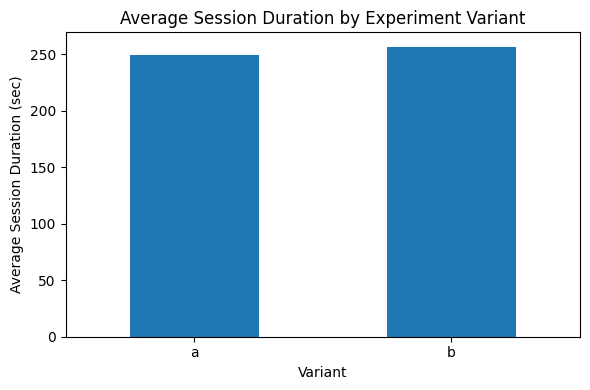

In [8]:
session_duration = df.groupby("variant")["session_duration_sec"].mean()

plt.figure(figsize=(6, 4))
session_duration.plot(kind="bar")
plt.title("Average Session Duration by Experiment Variant")
plt.xlabel("Variant")
plt.ylabel("Average Session Duration (sec)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
device_summary = df.groupby(["device_type", "variant"]).agg(
    signup_rate=("signed_up", "mean"),
    watch_start_rate=("watch_started", "mean"),
    avg_session_duration=("session_duration_sec", "mean")
).reset_index()

device_summary

,device_type,variant,signup_rate,watch_start_rate,avg_session_duration
0,desktop,a,0.059193,0.142704,251.143907
1,desktop,b,0.064641,0.162473,260.094888
2,mobile,a,0.061535,0.131187,247.967735
3,mobile,b,0.069480,0.151338,254.639425
4,tablet,a,0.058566,0.142231,254.021514
5,tablet,b,0.069467,0.169628,259.906300


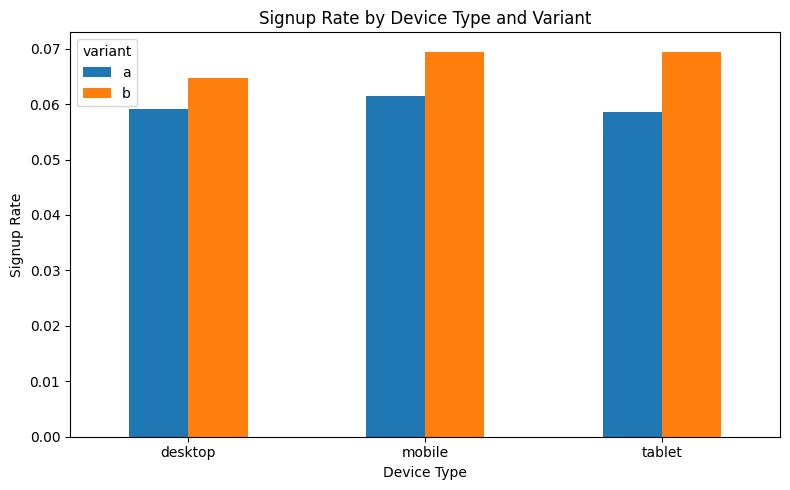

In [10]:
pivot_device = device_summary.pivot(index="device_type", columns="variant", values="signup_rate")

pivot_device.plot(kind="bar", figsize=(8, 5))
plt.title("Signup Rate by Device Type and Variant")
plt.xlabel("Device Type")
plt.ylabel("Signup Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
source_summary = df.groupby(["traffic_source", "variant"]).agg(
    signup_rate=("signed_up", "mean"),
    watch_start_rate=("watch_started", "mean"),
    avg_session_duration=("session_duration_sec", "mean")
).reset_index()

source_summary

,traffic_source,variant,signup_rate,watch_start_rate,avg_session_duration
0,direct,a,0.059349,0.152243,255.321755
1,direct,b,0.067533,0.168734,260.155936
2,email,a,0.072600,0.136612,247.990632
3,email,b,0.084726,0.157518,257.344073
4,organic,a,0.058221,0.136258,248.936449
5,organic,b,0.065079,0.156349,257.010450
6,paid_search,a,0.059564,0.121486,245.362099
7,paid_search,b,0.070928,0.149278,255.069897
8,paid_social,a,0.059936,0.132417,249.565512
9,paid_social,b,0.061758,0.150674,254.432911


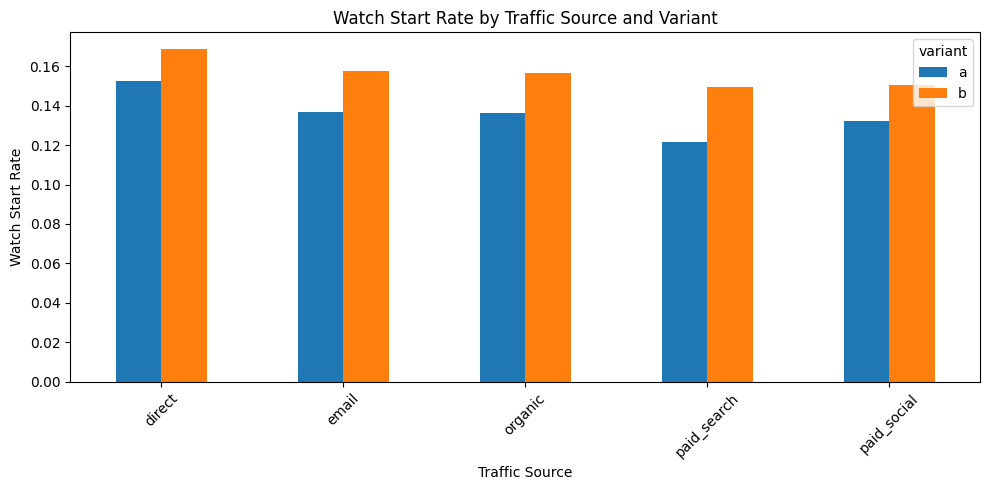

In [12]:
pivot_source = source_summary.pivot(index="traffic_source", columns="variant", values="watch_start_rate")

pivot_source.plot(kind="bar", figsize=(10, 5))
plt.title("Watch Start Rate by Traffic Source and Variant")
plt.xlabel("Traffic Source")
plt.ylabel("Watch Start Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

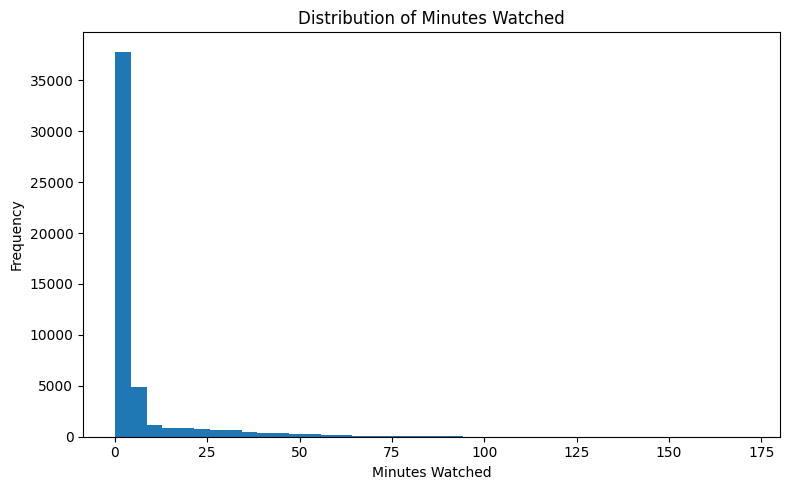

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df["minutes_watched"], bins=40)
plt.title("Distribution of Minutes Watched")
plt.xlabel("Minutes Watched")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [14]:
import os

os.makedirs("outputs/charts", exist_ok=True)

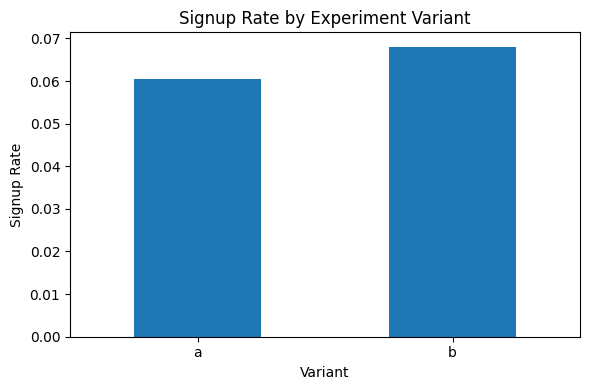

In [16]:
signup_rate = df.groupby("variant")["signed_up"].mean()

plt.figure(figsize=(6, 4))
signup_rate.plot(kind="bar")
plt.title("Signup Rate by Experiment Variant")
plt.xlabel("Variant")
plt.ylabel("Signup Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/charts/signup_rate_by_variant.png")
plt.show()


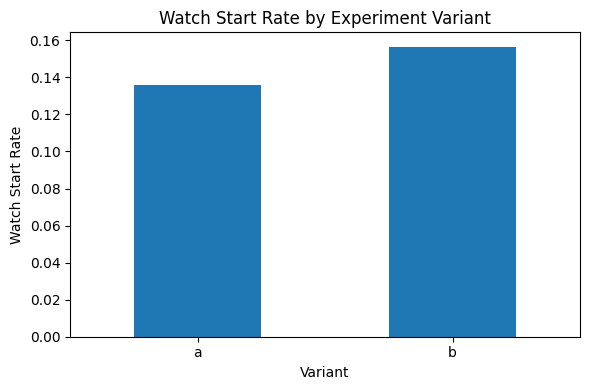

In [17]:
watch_rate = df.groupby("variant")["watch_started"].mean()

plt.figure(figsize=(6, 4))
watch_rate.plot(kind="bar")
plt.title("Watch Start Rate by Experiment Variant")
plt.xlabel("Variant")
plt.ylabel("Watch Start Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/charts/watch_start_rate_by_variant.png")
plt.show()

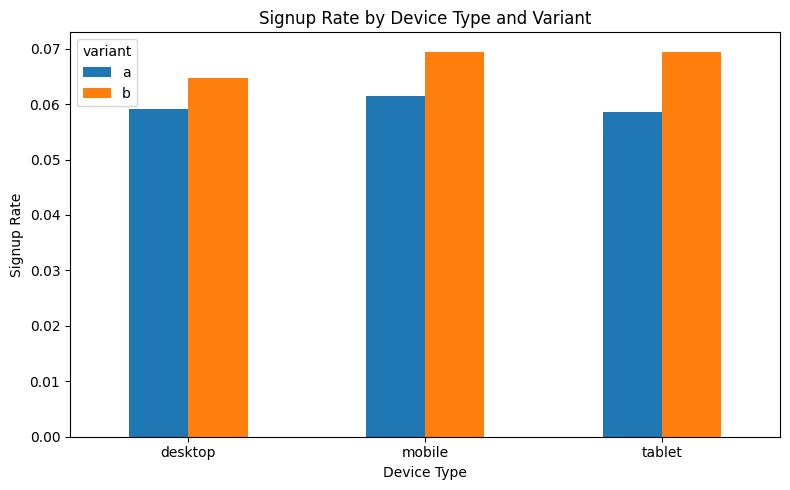

In [18]:
pivot_device.plot(kind="bar", figsize=(8, 5))
plt.title("Signup Rate by Device Type and Variant")
plt.xlabel("Device Type")
plt.ylabel("Signup Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/charts/signup_rate_by_device_variant.png")
plt.show()

### Initial EDA observations

- Variant B appears to outperform Variant A on signup rate and watch start rate.
- Desktop users show slightly higher conversion rates than mobile users.
- Email and direct traffic appear to produce stronger engagement than some paid channels.